## Build Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

np.random.seed(42)
n = 600

# Simulate student performance data — 6 features, 3 groups
# High performer, Average, Struggling
X, y_true = make_blobs(
    n_samples   = n,
    n_features  = 6,      # 6 dimensional data
    centers     = 3,
    cluster_std = 1.5,
    random_state= 42
)

# Add meaningful feature names
df = pd.DataFrame(X, columns=[
    'study_hours', 'sleep_hours', 'attendance',
    'prev_score',  'stress',      'exercise'
])
df['group'] = y_true
group_names = {0: 'High Performer', 1: 'Average', 2: 'Struggling'}

print("Data shape:", df.shape)
print("\nGroup counts:")
print(df['group'].value_counts())

Data shape: (600, 7)

Group counts:
group
2    200
1    200
0    200
Name: count, dtype: int64


## Step 1 — Scale Data


In [2]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('group', axis=1))

# t-SNE uses distance between points
# unscaled features with large ranges dominate distances
# always scale before t-SNE

## Step 2 — Apply t-SNE

In [4]:
tsne = TSNE(
    n_components = 2,
    # ↑ reduce to 2D for visualization
    #   can use 3 for 3D plots

    perplexity   = 30,
    # ↑ balance between local and global structure
    #   typical range: 5 to 50
    #   rule: should be less than n_samples

    max_iter       = 1000,
    # ↑ number of optimization iterations
    #   more iterations = better result but slower
    #   minimum recommended: 250

    learning_rate = 200,
    # ↑ controls how fast points move during optimization
    #   too low  → points clump in center
    #   too high → points spread too far apart
    #   'auto' works well in newer sklearn versions

    random_state  = 42,
    # ↑ t-SNE is stochastic — different runs give different layouts
    #   set random_state for reproducibility

    verbose       = 1
    # ↑ prints progress during optimization
)

X_tsne = tsne.fit_transform(X_scaled)
# X_tsne shape: (600, 2) → 2D coordinates for each point

print("\nt-SNE output shape:", X_tsne.shape)
print("KL Divergence (lower=better):", tsne.kl_divergence_)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 600 samples in 0.007s...
[t-SNE] Computed neighbors for 600 samples in 0.008s...
[t-SNE] Computed conditional probabilities for sample 600 / 600
[t-SNE] Mean sigma: 0.343099
[t-SNE] KL divergence after 250 iterations with early exaggeration: 57.643318
[t-SNE] KL divergence after 1000 iterations: 0.685928

t-SNE output shape: (600, 2)
KL Divergence (lower=better): 0.6859280467033386


## Step 3 — Visualize


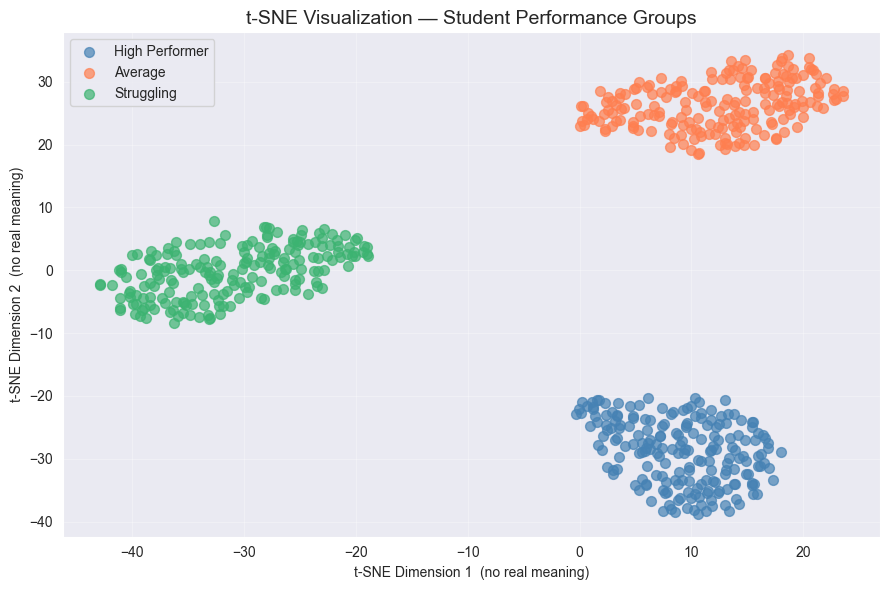

In [5]:
colors = ['steelblue', 'coral', 'mediumseagreen']

plt.figure(figsize=(9, 6))

for group_id in range(3):
    mask = y_true == group_id
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c      = colors[group_id],
        label  = group_names[group_id],
        alpha  = 0.7,
        s      = 50
    )

plt.title("t-SNE Visualization — Student Performance Groups", fontsize=14)
plt.xlabel("t-SNE Dimension 1  (no real meaning)")
plt.ylabel("t-SNE Dimension 2  (no real meaning)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Well separated clusters → groups are genuinely different
# Overlapping clusters   → groups share similar characteristics
# Axis labels have NO meaning in t-SNE — only relative positions matter

## Step 4 — Effect of Perplexity


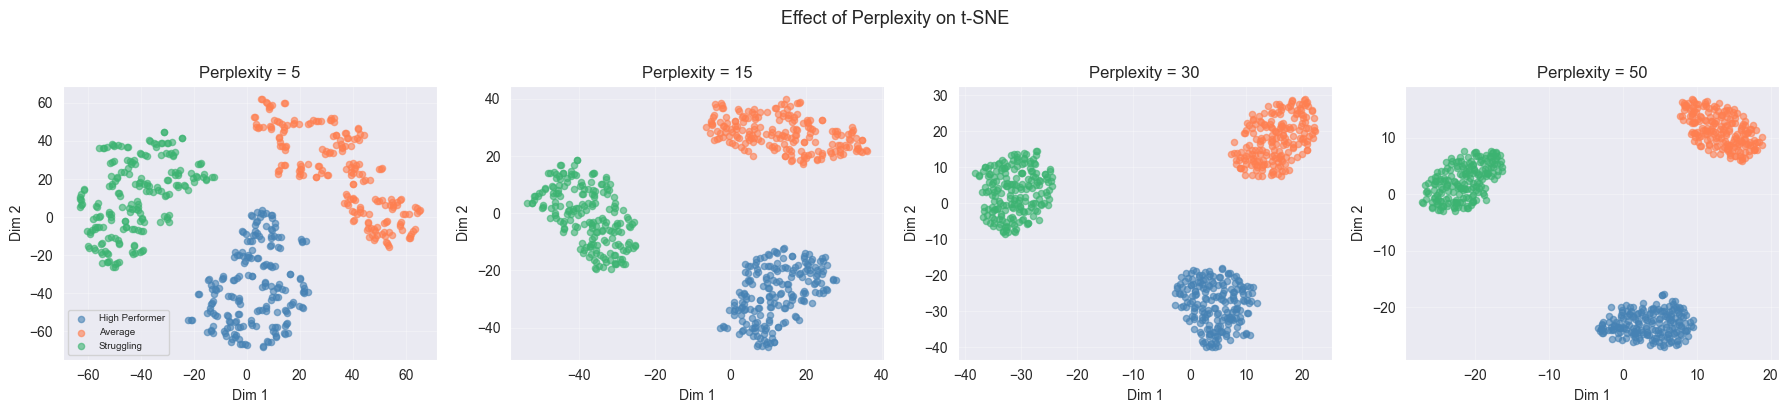

In [7]:
perplexities = [5, 15, 30, 50]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, perp in zip(axes, perplexities):
    tsne_temp = TSNE(
        n_components  = 2,
        perplexity    = perp,
        max_iter        = 1000,
        random_state  = 42
    )
    X_temp = tsne_temp.fit_transform(X_scaled)

    for group_id in range(3):
        mask = y_true == group_id
        ax.scatter(
            X_temp[mask, 0], X_temp[mask, 1],
            c=colors[group_id], alpha=0.6, s=20,
            label=group_names[group_id]
        )

    ax.set_title(f"Perplexity = {perp}")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=7)
plt.suptitle("Effect of Perplexity on t-SNE", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# perplexity=5  → many small isolated islands
# perplexity=30 → good balance, clear groups
# perplexity=50 → smoother but may over-merge groups

## Step 5 — t-SNE vs PCA Side by Side


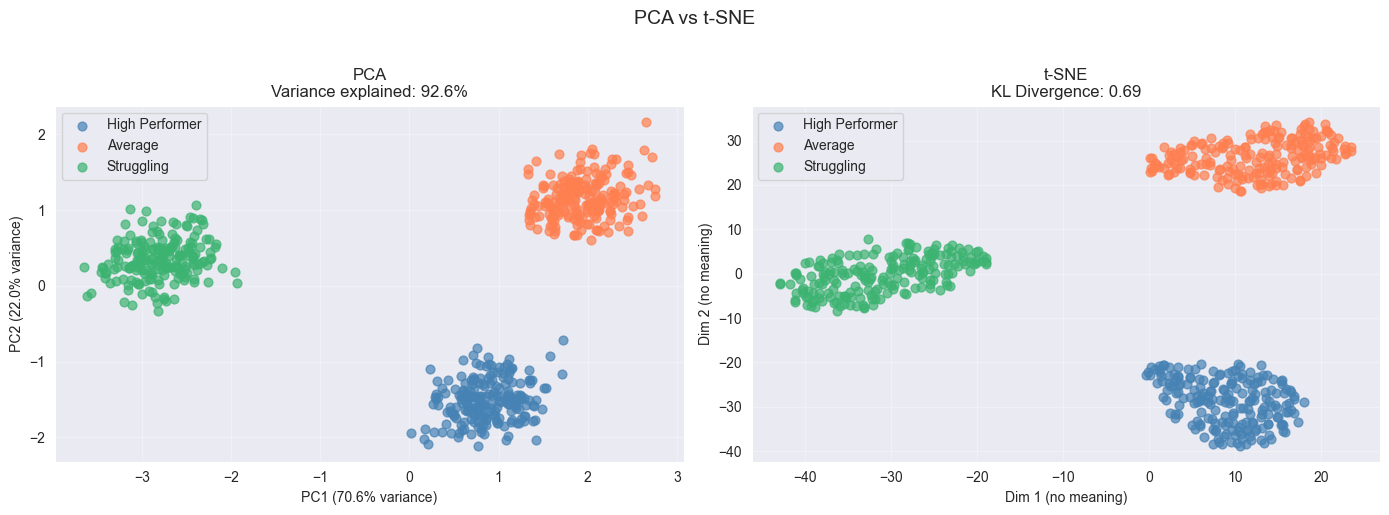

In [8]:
from sklearn.decomposition import PCA

# PCA reduction
pca       = PCA(n_components=2, random_state=42)
X_pca     = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA plot
for group_id in range(3):
    mask = y_true == group_id
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[group_id], alpha=0.7, s=40,
        label=group_names[group_id]
    )
axes[0].set_title(f"PCA\nVariance explained: "
                  f"{pca.explained_variance_ratio_.sum():.1%}")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# t-SNE plot
for group_id in range(3):
    mask = y_true == group_id
    axes[1].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=colors[group_id], alpha=0.7, s=40,
        label=group_names[group_id]
    )
axes[1].set_title(f"t-SNE\nKL Divergence: {tsne.kl_divergence_:.2f}")
axes[1].set_xlabel("Dim 1 (no meaning)")
axes[1].set_ylabel("Dim 2 (no meaning)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("PCA vs t-SNE", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# PCA: axes have meaning (variance explained)
#       faster, linear, good for preprocessing
# t-SNE: axes mean nothing
#         better cluster separation visually
#         non-linear, better for exploration

## Step 6 — Color by Individual Features


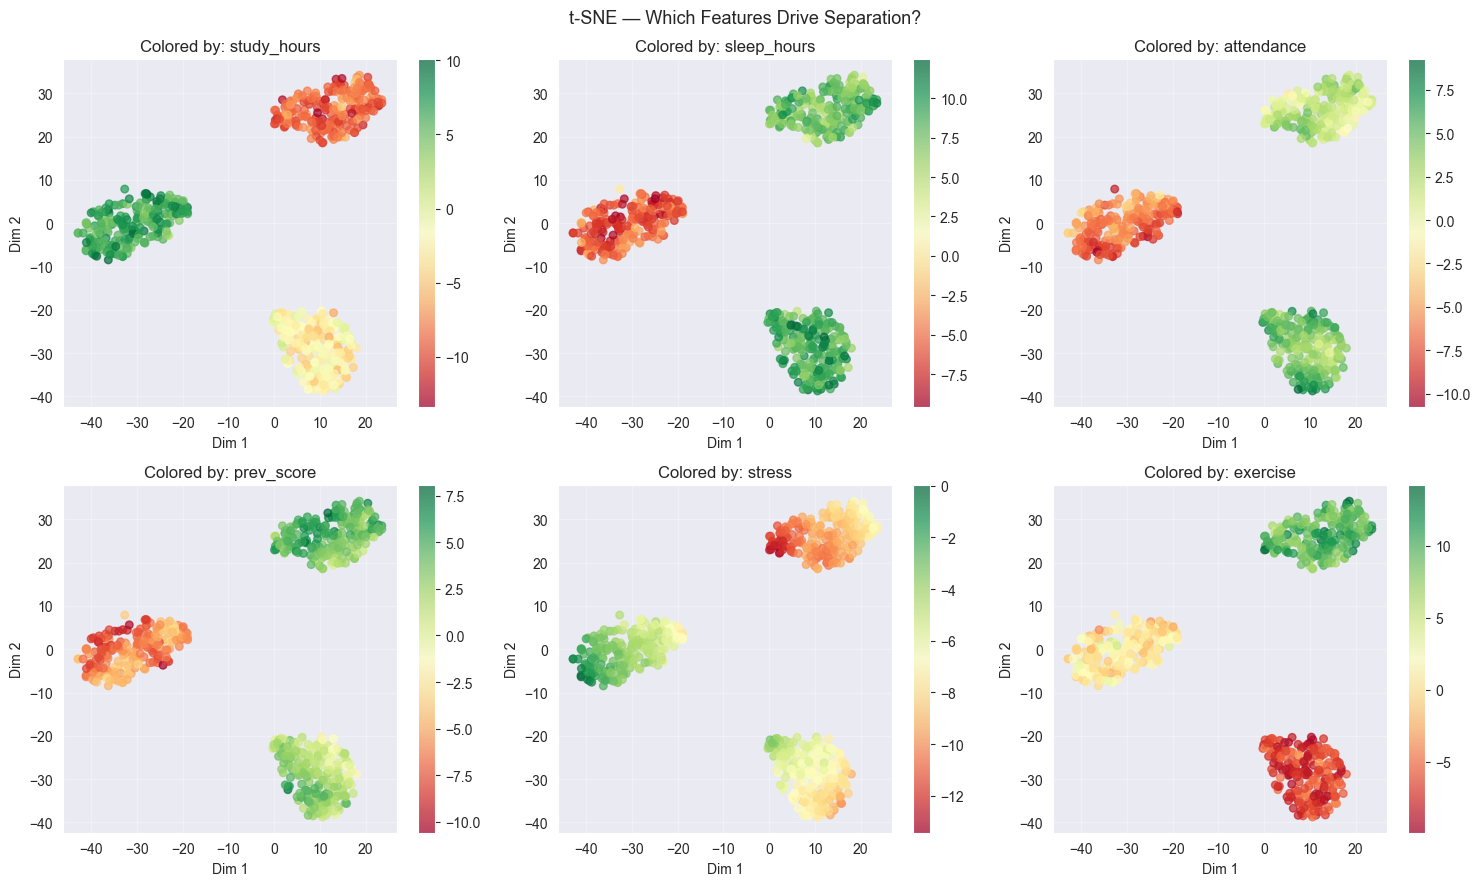

In [9]:
# Instead of true labels, color by each feature
# Helps understand which features drive the cluster separation

feature_cols = ['study_hours', 'sleep_hours', 'attendance',
                'prev_score',  'stress',      'exercise']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes      = axes.flatten()

for ax, feature in zip(axes, feature_cols):
    feature_vals = df[feature].values

    scatter = ax.scatter(
        X_tsne[:, 0], X_tsne[:, 1],
        c     = feature_vals,
        cmap  = 'RdYlGn',      # red=low, green=high
        alpha = 0.7,
        s     = 30
    )
    plt.colorbar(scatter, ax=ax)
    ax.set_title(f"Colored by: {feature}")
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
    ax.grid(True, alpha=0.3)

plt.suptitle("t-SNE — Which Features Drive Separation?", fontsize=13)
plt.tight_layout()
plt.show()

# If a feature's color gradient aligns with cluster separation
# → that feature is driving the cluster structure
# e.g. if study_hours shows red on left, green on right
#      → study_hours strongly separates the groups